# Week 7 final: model optimisation and trade-off

**Student:** Terry Benjamin Jr.  
**Programme:** CariSurg MedTech Pathways  
**Date:** 20 July 2026

This notebook asks whether a more complex model improves emergency-triage support
enough to justify its extra compute and lower interpretability. It reproduces the
Week 6 tuned logistic model, tunes a Random Forest and histogram gradient-boosting
model on training folds, benchmarks them on the unchanged holdout, and then
examines the ESI 1 cases that the recommended model misses.

This is retrospective coursework. It is not a clinical device and is not suitable
for autonomous triage.

## Decisions made before modelling

- Keep the Week 6 split exactly: 80/20, stratified by ESI, `random_state=42`.
- Keep the test set out of hyperparameter selection.
- Report accuracy, macro precision, macro recall, macro F1, training time,
  inference time per patient, and interpretability.
- Keep ESI 1 recall and raw counts beside the aggregate metrics. One test case
  changes ESI 1 recall by 6.25 percentage points.
- Exclude post-triage outcome fields and all free-text or administrative fields
  from model inputs.
- Use aggregate error analysis only. No row-level patient data is exported.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]

working_directory = Path.cwd()
repo_root = working_directory.parent if working_directory.name == "notebooks" else working_directory
docs_directory = repo_root / "docs"
docs_directory.mkdir(exist_ok=True)

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "text.color": "#222222",
        "font.size": 10,
    }
)

print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"random seed {RANDOM_STATE}")

pandas 2.3.3
numpy 2.0.2
scikit-learn 1.6.1
random seed 42


## Load and verify the Week 5 triage data

In [2]:
candidate_paths = [
    os.getenv("CARISURG_TRIAGE_CSV"),
    repo_root / "data" / "yaleemmlc_admissionprediction_triage.csv",
    repo_root / "week5" / "data" / "yaleemmlc_admissionprediction_triage.csv",
    working_directory / "yaleemmlc_admissionprediction_triage.csv",
]

data_path = next(
    (Path(path).expanduser() for path in candidate_paths if path and Path(path).expanduser().exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError(
        "Set CARISURG_TRIAGE_CSV to the full Week 5 triage CSV before running this notebook."
    )

triage = pd.read_csv(data_path).drop(columns=["Unnamed: 0"], errors="ignore")

assert triage.shape == (55121, 225)
assert set(triage["esi"].dropna().astype(int).unique()) == set(LABELS)
assert int(triage.duplicated().sum()) == 0
assert int(triage.isna().sum().sum()) == 0

quality_check = pd.DataFrame(
    {
        "check": ["visits", "columns", "missing cells", "duplicate rows"],
        "result": [
            f"{triage.shape[0]:,}",
            triage.shape[1],
            int(triage.isna().sum().sum()),
            int(triage.duplicated().sum()),
        ],
    }
)

print(f"Loaded {triage.shape[0]:,} visits and {triage.shape[1]} columns.")
quality_check

Loaded 55,121 visits and 225 columns.


,check,result
0,visits,"55,121"
1,columns,225
2,missing cells,0
3,duplicate rows,0


## Recreate the Week 6 features and holdout

`disposition` and `previousdispo` are excluded because they are known after the
triage decision. Text and administrative categories are also excluded. The
remaining numeric set contains arrival vitals, age, oxygen-device information,
and 200 binary chief-complaint flags.

In [3]:
target = "esi"
leakage_columns = ["disposition", "previousdispo"]
non_numeric_columns = triage.select_dtypes(exclude="number").columns.tolist()
excluded = set([target] + leakage_columns + non_numeric_columns)

base_feature_columns = [
    column
    for column in triage.columns
    if column not in excluded and pd.api.types.is_numeric_dtype(triage[column])
]

X = triage[base_feature_columns].copy()
y = triage[target].astype(int)

assert len(base_feature_columns) == 209
assert X.select_dtypes(exclude="number").empty
assert np.isfinite(X.to_numpy()).all()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

test_index_hash = hashlib.sha256(
    ",".join(map(str, X_test.index)).encode("utf-8")
).hexdigest()
test_class_counts = y_test.value_counts().sort_index()

assert len(X_train) == 44096
assert len(X_test) == 11025
assert test_class_counts.to_dict() == {1: 16, 2: 3585, 3: 5402, 4: 1779, 5: 243}

split_summary = pd.DataFrame(
    {
        "training visits": [len(X_train)],
        "test visits": [len(X_test)],
        "training ESI 1 visits": [int((y_train == 1).sum())],
        "test ESI 1 visits": [int((y_test == 1).sum())],
        "test index SHA-256": [test_index_hash],
    }
)

print("The split matches Week 6: test_size=0.20, stratify=y, random_state=42.")
split_summary

The split matches Week 6: test_size=0.20, stratify=y, random_state=42.


,training visits,test visits,training ESI 1 visits,test ESI 1 visits,test index SHA-256
0,44096,11025,61,16,5e31ff9f74281290a36280585ecab4a22f5cb2b1ca48a6...


## Add clinically legible features

The engineered features follow the Week 7 tutorial. They combine existing
arrival measurements without using future information. Several flags cover
different physiological systems so the model is not forced to rely on blood
pressure alone. These thresholds are modelling features, not diagnostic rules.

In [4]:
def add_clinical_features(frame):
    enriched = frame.copy()
    systolic = enriched["triage_vital_sbp"].replace(0, np.nan)
    respiratory_rate = enriched["triage_vital_rr"].replace(0, np.nan)

    enriched["shock_index"] = enriched["triage_vital_hr"] / systolic
    enriched["pulse_pressure"] = (
        enriched["triage_vital_sbp"] - enriched["triage_vital_dbp"]
    )
    enriched["spo2_rr_ratio"] = enriched["triage_vital_o2"] / respiratory_rate

    enriched["red_flag_hypoxia"] = (enriched["triage_vital_o2"] < 92).astype(int)
    enriched["red_flag_tachypnea"] = (enriched["triage_vital_rr"] > 20).astype(int)
    enriched["red_flag_fever"] = (enriched["triage_vital_temp"] >= 100.4).astype(int)
    enriched["red_flag_hypothermia"] = (
        enriched["triage_vital_temp"] < 96.8
    ).astype(int)
    enriched["red_flag_bradycardia"] = (
        enriched["triage_vital_hr"] < 60
    ).astype(int)
    enriched["red_flag_hyperglycaemia"] = (
        enriched["triage_glucose"] > 180
    ).astype(int)
    enriched["respiratory_distress"] = (
        (enriched["red_flag_hypoxia"] == 1)
        | (enriched["red_flag_tachypnea"] == 1)
    ).astype(int)
    enriched["red_flag_count"] = enriched[
        [
            "red_flag_hypoxia",
            "red_flag_tachypnea",
            "red_flag_fever",
            "red_flag_hypothermia",
            "red_flag_bradycardia",
            "red_flag_hyperglycaemia",
        ]
    ].sum(axis=1)

    return enriched.replace([np.inf, -np.inf], np.nan).fillna(0)


X_train_enriched = add_clinical_features(X_train)
X_test_enriched = add_clinical_features(X_test)

assert list(X_train_enriched.columns) == list(X_test_enriched.columns)
assert X_train_enriched.shape[1] == 220
assert np.isfinite(X_train_enriched.to_numpy()).all()
assert np.isfinite(X_test_enriched.to_numpy()).all()

engineered_columns = [
    column for column in X_train_enriched.columns if column not in X_train.columns
]
pd.DataFrame({"engineered feature": engineered_columns})

,engineered feature
0,shock_index
1,pulse_pressure
2,spo2_rr_ratio
3,red_flag_hypoxia
4,red_flag_tachypnea
5,red_flag_fever
6,red_flag_hypothermia
7,red_flag_bradycardia
8,red_flag_hyperglycaemia
9,respiratory_distress


## Evaluation and timing helpers

In [5]:
def esi_one_recall(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=[1],
        average=None,
        zero_division=0,
    )[0]


def choose_refit_candidate(results):
    scores = pd.DataFrame(
        {
            "macro_f1": results["mean_test_macro_f1"],
            "esi_1_recall": results["mean_test_esi_1_recall"],
        }
    )
    competitive = scores["macro_f1"] >= scores["macro_f1"].max() - 0.015
    return int(
        scores.loc[competitive]
        .sort_values(["esi_1_recall", "macro_f1"], ascending=False)
        .index[0]
    )


def timed_fit_and_predict(model, X_fit, y_fit, X_holdout, inference_repeats=7):
    fit_start = perf_counter()
    model.fit(X_fit, y_fit)
    train_seconds = perf_counter() - fit_start

    model.predict(X_holdout.iloc[:1])
    inference_runs = []
    predictions = None
    for _ in range(inference_repeats):
        inference_start = perf_counter()
        predictions = model.predict(X_holdout)
        inference_runs.append(perf_counter() - inference_start)

    inference_seconds = float(np.median(inference_runs))
    return model, predictions, train_seconds, inference_seconds * 1000 / len(X_holdout)


def summarise_model(
    name,
    y_true,
    y_pred,
    train_seconds,
    inference_ms,
    interpretability,
    interpretability_reason,
):
    matrix = confusion_matrix(y_true, y_pred, labels=LABELS)
    esi_1_caught = int(matrix[0, 0])
    esi_1_total = int(matrix[0].sum())

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "esi_1_recall": esi_1_caught / esi_1_total,
        "esi_1_caught": esi_1_caught,
        "esi_1_missed": esi_1_total - esi_1_caught,
        "train_seconds": train_seconds,
        "inference_ms_per_patient": inference_ms,
        "interpretability": interpretability,
        "interpretability_reason": interpretability_reason,
    }


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "macro_f1": "f1_macro",
    "esi_1_recall": make_scorer(esi_one_recall),
}

## Reproduce the tuned Week 6 logistic model

This row is the baseline to beat. It uses the original Week 6 numeric feature set
and the class weight selected on the Week 6 training data.

In [6]:
logistic_baseline = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                class_weight={1: 8},
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

(
    logistic_baseline,
    logistic_predictions,
    logistic_train_seconds,
    logistic_inference_ms,
) = timed_fit_and_predict(logistic_baseline, X_train, y_train, X_test)

logistic_result = summarise_model(
    "Week 6 tuned logistic",
    y_test,
    logistic_predictions,
    logistic_train_seconds,
    logistic_inference_ms,
    "High",
    "Scaled coefficients give a direct direction and strength for each class.",
)

pd.DataFrame([logistic_result]).set_index("model").drop(
    columns=["interpretability_reason"]
).round(4)

,accuracy,macro_precision,macro_recall,macro_f1,esi_1_recall,esi_1_caught,esi_1_missed,train_seconds,inference_ms_per_patient,interpretability
model,,,,,,,,,,
Week 6 tuned logistic,0.6805,0.5527,0.5115,0.5009,0.4375,7,9,3.3581,0.0012,High


## Tune the Random Forest on training folds

The search expands the interim pass to 12 candidates. The refit rule first keeps
settings within 0.015 macro F1 of the strongest candidate, then favours the
highest ESI 1 recall. This prevents a weak overall model from winning solely
because of the rare class while still treating the critical class seriously.

In [7]:
rf_parameter_space = {
    "n_estimators": [150, 250, 350],
    "max_depth": [None, 10, 16, 22],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"],
    "class_weight": [
        "balanced",
        "balanced_subsample",
        {1: 6, 2: 1.5, 3: 1, 4: 1, 5: 1},
        {1: 10, 2: 2, 3: 1, 4: 1, 5: 1},
        {1: 16, 2: 2, 3: 1, 4: 1, 5: 1},
    ],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_parameter_space,
    n_iter=12,
    scoring=scoring,
    refit=choose_refit_candidate,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)

rf_search_start = perf_counter()
rf_search.fit(X_train_enriched, y_train)
rf_search_seconds = perf_counter() - rf_search_start

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_summary = (
    rf_cv_results[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "mean_test_esi_1_recall",
            "mean_fit_time",
            "params",
        ]
    ]
    .sort_values(["mean_test_macro_f1", "mean_test_esi_1_recall"], ascending=False)
    .reset_index(drop=True)
)
rf_cv_summary.to_csv(docs_directory / "week7_final_random_forest_cv.csv", index=False)

print(f"Random Forest search time: {rf_search_seconds:.1f} seconds")
print("Selected parameters:")
print(json.dumps(rf_search.best_params_, indent=2))
rf_cv_summary.head(10).round(4)

Random Forest search time: 154.3 seconds
Selected parameters:
{
  "n_estimators": 150,
  "min_samples_leaf": 8,
  "max_features": "sqrt",
  "max_depth": null,
  "class_weight": "balanced"
}


,rank_test_macro_f1,mean_test_macro_f1,mean_test_esi_1_recall,mean_fit_time,params
0,1,0.4353,0.2611,26.1958,"{'n_estimators': 150, 'min_samples_leaf': 8, '..."
1,2,0.4317,0.1325,50.1341,"{'n_estimators': 350, 'min_samples_leaf': 2, '..."
2,3,0.4235,0.0992,43.8359,"{'n_estimators': 250, 'min_samples_leaf': 2, '..."
3,4,0.4020,0.0000,49.2524,"{'n_estimators': 250, 'min_samples_leaf': 1, '..."
4,5,0.4009,0.0667,26.2731,"{'n_estimators': 150, 'min_samples_leaf': 2, '..."
5,6,0.3587,0.0167,57.4769,"{'n_estimators': 250, 'min_samples_leaf': 8, '..."
6,7,0.3306,0.0000,37.7943,"{'n_estimators': 250, 'min_samples_leaf': 2, '..."
7,8,0.3109,0.0000,27.7092,"{'n_estimators': 250, 'min_samples_leaf': 1, '..."
8,9,0.2986,0.0000,20.7989,"{'n_estimators': 350, 'min_samples_leaf': 2, '..."
9,10,0.2717,0.0000,13.0238,"{'n_estimators': 150, 'min_samples_leaf': 2, '..."


## Tune histogram gradient boosting on training folds

Gradient boosting is included because the tutorial identifies it as a strong
candidate for tabular clinical data. Eight sampled settings cover learning rate,
tree depth, number of boosting rounds, leaf size, and regularisation.

In [8]:
hgb_parameter_space = {
    "learning_rate": [0.03, 0.05, 0.08, 0.10],
    "max_iter": [120, 200, 300],
    "max_depth": [None, 4, 6, 8],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 40],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    param_distributions=hgb_parameter_space,
    n_iter=8,
    scoring=scoring,
    refit=choose_refit_candidate,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)

hgb_search_start = perf_counter()
hgb_search.fit(X_train_enriched, y_train)
hgb_search_seconds = perf_counter() - hgb_search_start

hgb_cv_results = pd.DataFrame(hgb_search.cv_results_)
hgb_cv_summary = (
    hgb_cv_results[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "mean_test_esi_1_recall",
            "mean_fit_time",
            "params",
        ]
    ]
    .sort_values(["mean_test_macro_f1", "mean_test_esi_1_recall"], ascending=False)
    .reset_index(drop=True)
)
hgb_cv_summary.to_csv(docs_directory / "week7_final_gradient_boosting_cv.csv", index=False)

print(f"Gradient-boosting search time: {hgb_search_seconds:.1f} seconds")
print("Selected parameters:")
print(json.dumps(hgb_search.best_params_, indent=2))
hgb_cv_summary.head(10).round(4)

Gradient-boosting search time: 108.2 seconds
Selected parameters:
{
  "min_samples_leaf": 10,
  "max_leaf_nodes": 63,
  "max_iter": 200,
  "max_depth": null,
  "learning_rate": 0.08,
  "l2_regularization": 1.0
}


,rank_test_macro_f1,mean_test_macro_f1,mean_test_esi_1_recall,mean_fit_time,params
0,1,0.4628,0.2929,30.0769,"{'min_samples_leaf': 10, 'max_leaf_nodes': 63,..."
1,2,0.4375,0.2587,22.8125,"{'min_samples_leaf': 20, 'max_leaf_nodes': 31,..."
2,3,0.4165,0.2095,17.7634,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."
3,4,0.3979,0.4238,25.3044,"{'min_samples_leaf': 10, 'max_leaf_nodes': 15,..."
4,5,0.3971,0.0325,17.7003,"{'min_samples_leaf': 40, 'max_leaf_nodes': 31,..."
5,6,0.3948,0.3238,23.2217,"{'min_samples_leaf': 20, 'max_leaf_nodes': 15,..."
6,7,0.3938,0.1135,31.3021,"{'min_samples_leaf': 40, 'max_leaf_nodes': 31,..."
7,8,0.3847,0.3063,26.5546,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."


## Refit selected candidates and benchmark the unchanged test set

Search time is not counted as final training time. Each selected candidate is
fitted once from its chosen settings, then inference is timed seven times over
the full holdout. The median batch time is divided by 11,025 visits.

In [9]:
tuned_forest = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
(
    tuned_forest,
    forest_predictions,
    forest_train_seconds,
    forest_inference_ms,
) = timed_fit_and_predict(
    tuned_forest,
    X_train_enriched,
    y_train,
    X_test_enriched,
)

forest_result = summarise_model(
    "Tuned Random Forest",
    y_test,
    forest_predictions,
    forest_train_seconds,
    forest_inference_ms,
    "Medium",
    "Global feature importance is available, but hundreds of trees do not give one simple patient-level path.",
)

tuned_boosting = HistGradientBoostingClassifier(
    **hgb_search.best_params_,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
(
    tuned_boosting,
    boosting_predictions,
    boosting_train_seconds,
    boosting_inference_ms,
) = timed_fit_and_predict(
    tuned_boosting,
    X_train_enriched,
    y_train,
    X_test_enriched,
)

boosting_result = summarise_model(
    "Tuned gradient boosting",
    y_test,
    boosting_predictions,
    boosting_train_seconds,
    boosting_inference_ms,
    "Low",
    "A faithful patient-level account would require a separate method such as SHAP.",
)

benchmark = pd.DataFrame(
    [logistic_result, forest_result, boosting_result]
).set_index("model")
benchmark.to_csv(docs_directory / "week7_final_benchmark.csv")

benchmark.drop(columns=["interpretability_reason"]).round(4)

,accuracy,macro_precision,macro_recall,macro_f1,esi_1_recall,esi_1_caught,esi_1_missed,train_seconds,inference_ms_per_patient,interpretability
model,,,,,,,,,,
Week 6 tuned logistic,0.6805,0.5527,0.5115,0.5009,0.4375,7,9,3.3581,0.0012,High
Tuned Random Forest,0.5718,0.4248,0.5359,0.4441,0.3125,5,11,4.9776,0.0078,Medium
Tuned gradient boosting,0.6230,0.4602,0.5884,0.4847,0.3750,6,10,28.6316,0.0153,Low


## Six-axis comparison plus interpretability

The four score axes use macro averaging so every ESI class contributes equally.
ESI 1 recall is shown separately because missing an immediate-care patient has a
different clinical consequence from an error in a less urgent class.

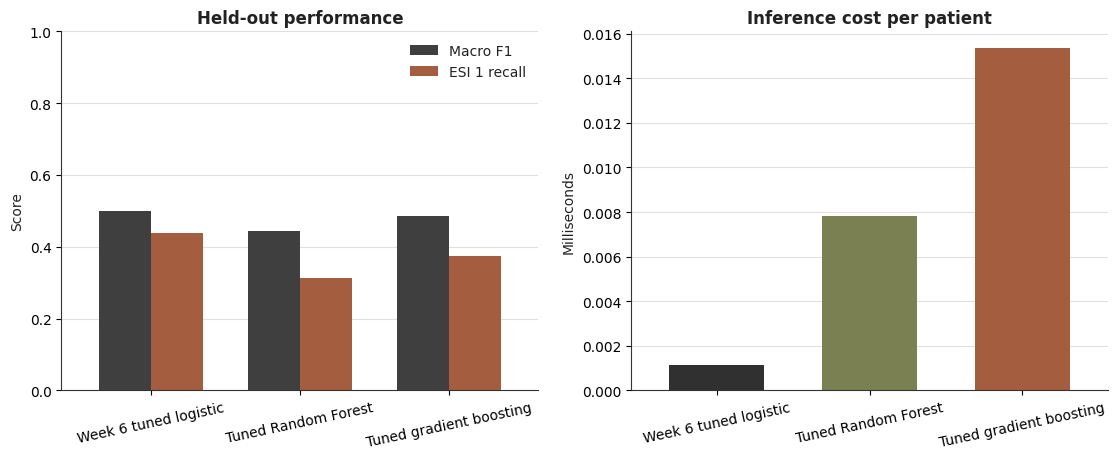

Saved week7_final_model_comparison.png


In [10]:
palette = ["#303030", "#7A8052", "#A45D3F"]

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.7))
benchmark[["macro_f1", "esi_1_recall"]].plot(
    kind="bar",
    color=["#3F3F3F", "#A45D3F"],
    width=0.70,
    ax=axes[0],
)
axes[0].set_title("Held-out performance", weight="bold")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=12)
axes[0].legend(["Macro F1", "ESI 1 recall"], frameon=False)

benchmark["inference_ms_per_patient"].plot(
    kind="bar",
    color=palette,
    width=0.62,
    ax=axes[1],
)
axes[1].set_title("Inference cost per patient", weight="bold")
axes[1].set_ylabel("Milliseconds")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=12)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E3E0DB", linewidth=0.8)
    ax.set_axisbelow(True)

fig.tight_layout()
comparison_path = docs_directory / "week7_final_model_comparison.png"
fig.savefig(comparison_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved {comparison_path.name}")

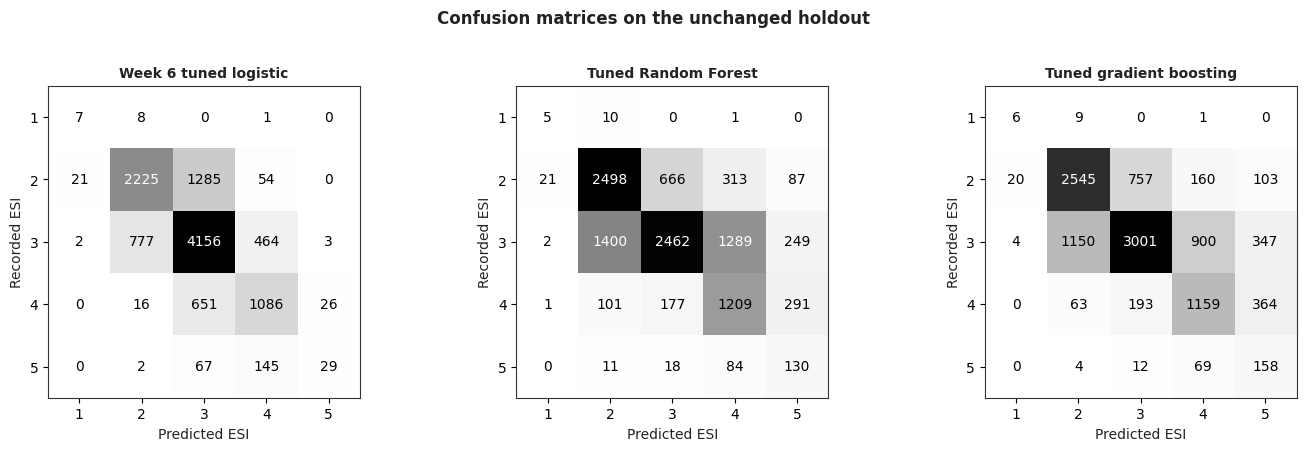

Saved week7_final_confusion_comparison.png


In [11]:
prediction_map = {
    "Week 6 tuned logistic": logistic_predictions,
    "Tuned Random Forest": forest_predictions,
    "Tuned gradient boosting": boosting_predictions,
}

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.3))
for ax, model_name in zip(axes, benchmark.index):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction_map[model_name],
        labels=LABELS,
        display_labels=[str(label) for label in LABELS],
        cmap="Greys",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name, weight="bold", fontsize=10)
    ax.set_xlabel("Predicted ESI")
    ax.set_ylabel("Recorded ESI")

fig.suptitle("Confusion matrices on the unchanged holdout", weight="bold", y=1.03)
fig.tight_layout()
confusion_path = docs_directory / "week7_final_confusion_comparison.png"
fig.savefig(confusion_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved {confusion_path.name}")

## Interpretability assessment

The one-minute test is practical: could Dr. Reyes be told why one patient
received a prediction without hiding behind a global score? Logistic regression
passes most directly. Random Forest provides a useful global importance view,
but not one path through all trees. Gradient boosting needs an additional local
explanation method before it passes.

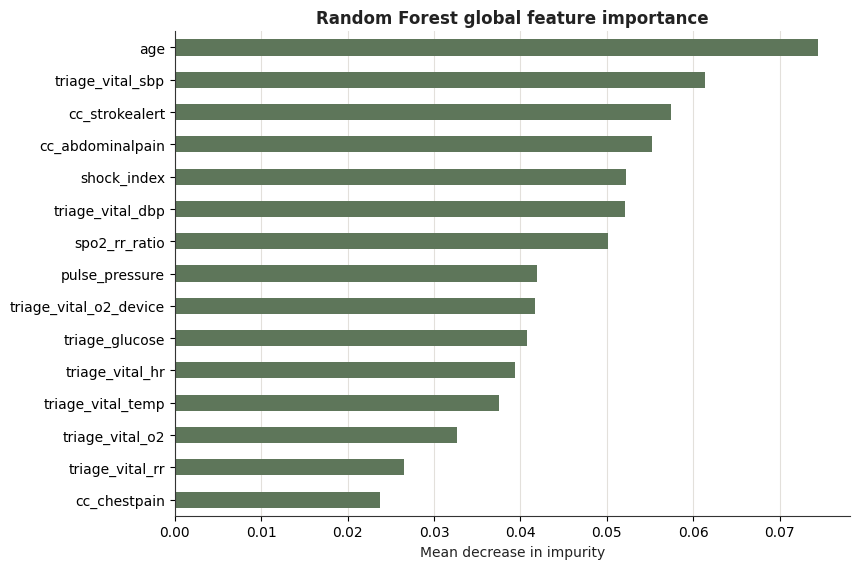

,interpretability,interpretability_reason
model,,
Week 6 tuned logistic,High,Scaled coefficients give a direct direction an...
Tuned Random Forest,Medium,"Global feature importance is available, but hu..."
Tuned gradient boosting,Low,A faithful patient-level account would require...


In [12]:
forest_importance = (
    pd.Series(
        tuned_forest.feature_importances_,
        index=X_train_enriched.columns,
        name="importance",
    )
    .sort_values(ascending=False)
)
forest_importance.to_csv(docs_directory / "week7_final_feature_importance.csv", header=True)

top_importance = forest_importance.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8.7, 5.8))
top_importance.plot(kind="barh", color="#5E765A", ax=ax)
ax.set_title("Random Forest global feature importance", weight="bold")
ax.set_xlabel("Mean decrease in impurity")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#E3E0DB", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()

importance_path = docs_directory / "week7_final_feature_importance.png"
fig.savefig(importance_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

interpretability_table = benchmark[
    ["interpretability", "interpretability_reason"]
].copy()
interpretability_table

## Choose a model for the error review

The recommendation rule is deliberately conservative. A complex model must
deliver a material macro-F1 gain, not merely a rounding difference, and it must
not weaken ESI 1 recall. Otherwise the tuned logistic model remains the more
defensible Phase 3 candidate because it is easier to audit and explain.

In [13]:
complex_rows = benchmark.loc[["Tuned Random Forest", "Tuned gradient boosting"]]
best_complex_name = complex_rows["macro_f1"].idxmax()
best_complex = benchmark.loc[best_complex_name]
baseline = benchmark.loc["Week 6 tuned logistic"]

material_macro_gain = best_complex["macro_f1"] - baseline["macro_f1"] >= 0.01
no_esi_1_loss = best_complex["esi_1_recall"] >= baseline["esi_1_recall"]

if material_macro_gain and no_esi_1_loss:
    recommended_model = best_complex_name
else:
    recommended_model = "Week 6 tuned logistic"

recommended_predictions = prediction_map[recommended_model]

decision_summary = pd.DataFrame(
    {
        "measure": [
            "best complex candidate",
            "macro-F1 gain over baseline",
            "ESI 1 recall change",
            "recommended model",
        ],
        "result": [
            best_complex_name,
            f'{best_complex["macro_f1"] - baseline["macro_f1"]:+.4f}',
            f'{best_complex["esi_1_recall"] - baseline["esi_1_recall"]:+.1%}',
            recommended_model,
        ],
    }
)
decision_summary

,measure,result
0,best complex candidate,Tuned gradient boosting
1,macro-F1 gain over baseline,-0.0162
2,ESI 1 recall change,-6.2%
3,recommended model,Week 6 tuned logistic


## ESI 1 error analysis

The review starts with the 16 recorded ESI 1 visits in the test set. It counts
which were caught or under-triaged, then compares aggregate vital-sign patterns
and complaint flags. "Near-normal" below is a transparent screening definition
used only to describe a pattern: heart rate 60-100, respiratory rate 12-20,
oxygen saturation at least 94%, systolic pressure at least 100, and temperature
96.8-100.4 F.

In [14]:
esi_1_mask = (y_test == 1).to_numpy()
esi_1_rows = X_test.loc[y_test == 1].copy()
esi_1_rows["prediction"] = recommended_predictions[esi_1_mask]
esi_1_rows["outcome"] = np.where(esi_1_rows["prediction"] == 1, "caught", "missed")
esi_1_rows["near_normal_vitals"] = (
    esi_1_rows["triage_vital_hr"].between(60, 100)
    & esi_1_rows["triage_vital_rr"].between(12, 20)
    & (esi_1_rows["triage_vital_o2"] >= 94)
    & (esi_1_rows["triage_vital_sbp"] >= 100)
    & esi_1_rows["triage_vital_temp"].between(96.8, 100.4)
)

error_counts = (
    esi_1_rows["outcome"]
    .value_counts()
    .reindex(["caught", "missed"], fill_value=0)
)
near_normal_counts = (
    esi_1_rows.groupby("outcome")["near_normal_vitals"]
    .agg(["sum", "count"])
    .reindex(["caught", "missed"], fill_value=0)
)
near_normal_counts["share"] = (
    near_normal_counts["sum"] / near_normal_counts["count"].replace(0, np.nan)
)

vital_columns = [
    "age",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_o2_device",
    "triage_vital_temp",
    "triage_glucose",
]
vital_profile = (
    esi_1_rows.groupby("outcome")[vital_columns]
    .median()
    .T
    .rename_axis("measure")
)
vital_profile.to_csv(docs_directory / "week7_final_esi1_vital_profile.csv")

print(f"Recommended model: {recommended_model}")
print(error_counts.to_string())
near_normal_counts.round(3)

Recommended model: Week 6 tuned logistic
outcome
caught    7
missed    9


,sum,count,share
outcome,,,
caught,3,7,0.429
missed,3,9,0.333


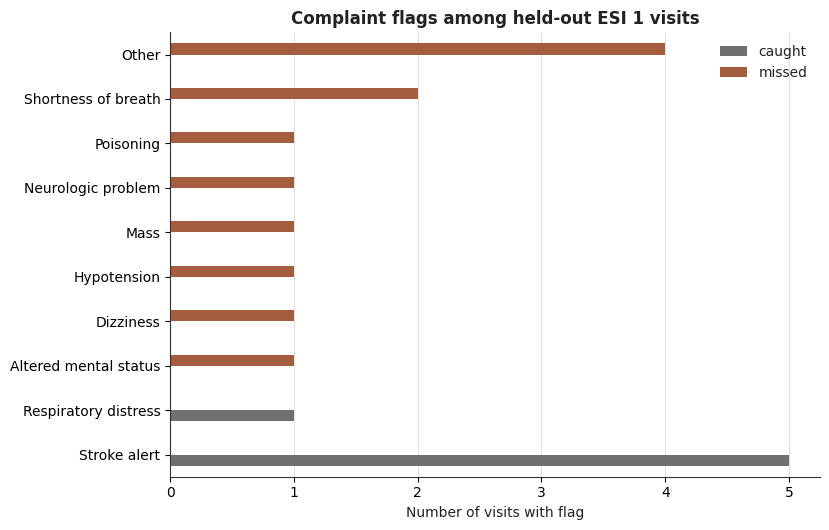

Top complaint flags:


,caught,missed,total_esi_1
other,0.0,4.0,4.0
shortnessofbreath,0.0,2.0,2.0
alteredmentalstatus,0.0,1.0,1.0
dizziness,0.0,1.0,1.0
hypotension,0.0,1.0,1.0
mass,0.0,1.0,1.0
neurologicproblem,0.0,1.0,1.0
poisoning,0.0,1.0,1.0
strokealert,5.0,0.0,5.0
respiratorydistress,1.0,0.0,1.0


In [15]:
complaint_columns = [column for column in X_test.columns if column.startswith("cc_")]
complaint_frame = esi_1_rows[complaint_columns].copy()
complaint_frame["outcome"] = esi_1_rows["outcome"]

complaint_summary = pd.DataFrame(
    {
        "caught": complaint_frame.loc[
            complaint_frame["outcome"] == "caught", complaint_columns
        ].sum(),
        "missed": complaint_frame.loc[
            complaint_frame["outcome"] == "missed", complaint_columns
        ].sum(),
    }
)
complaint_summary["total_esi_1"] = (
    complaint_summary["caught"] + complaint_summary["missed"]
)
complaint_summary = complaint_summary.loc[
    complaint_summary["total_esi_1"] > 0
].sort_values(["missed", "total_esi_1", "caught"], ascending=False)
complaint_summary.index = complaint_summary.index.str.replace("cc_", "", regex=False)
complaint_summary.to_csv(docs_directory / "week7_final_esi1_complaint_patterns.csv")

top_missed = complaint_summary.head(10).sort_values("missed")
complaint_display_names = {
    "alteredmentalstatus": "Altered mental status",
    "dizziness": "Dizziness",
    "hypotension": "Hypotension",
    "mass": "Mass",
    "neurologicproblem": "Neurologic problem",
    "other": "Other",
    "poisoning": "Poisoning",
    "respiratorydistress": "Respiratory distress",
    "shortnessofbreath": "Shortness of breath",
    "strokealert": "Stroke alert",
}
top_missed.index = [
    complaint_display_names.get(name, name.replace("_", " ").title())
    for name in top_missed.index
]
fig, ax = plt.subplots(figsize=(8.4, 5.4))
top_missed[["caught", "missed"]].plot(
    kind="barh",
    color=["#707070", "#A45D3F"],
    ax=ax,
)
ax.set_title("Complaint flags among held-out ESI 1 visits", weight="bold")
ax.set_xlabel("Number of visits with flag")
ax.set_ylabel("")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#E3E0DB", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()

complaint_path = docs_directory / "week7_final_esi1_complaints.png"
fig.savefig(complaint_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

print("Top complaint flags:")
complaint_summary.head(12)

## Write the benchmark artefacts

The exported table is the compact evidence used by the cost-benefit memo. It
keeps all seven comparison dimensions and the ESI 1 count together.

In [16]:
def fmt_score(value):
    return f"{value:.3f}"


table_rows = []
for model_name, row in benchmark.iterrows():
    feature_note = (
        "Week 6 numeric set"
        if model_name == "Week 6 tuned logistic"
        else "Week 6 set + 11 engineered features"
    )
    table_rows.append(
        [
            model_name,
            feature_note,
            fmt_score(row["accuracy"]),
            fmt_score(row["macro_precision"]),
            fmt_score(row["macro_recall"]),
            fmt_score(row["macro_f1"]),
            f'{int(row["esi_1_caught"])}/16 ({row["esi_1_recall"]:.1%})',
            f'{row["train_seconds"]:.2f}',
            f'{row["inference_ms_per_patient"]:.4f}',
            row["interpretability"],
        ]
    )

headers = [
    "Model",
    "Features",
    "Accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "ESI 1 caught",
    "Train (s)",
    "Inference (ms/patient)",
    "Interpretability",
]
separator = ["---"] * len(headers)
markdown_table = "\n".join(
    [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(separator) + " |",
        *["| " + " | ".join(row) + " |" for row in table_rows],
    ]
)

recommended = benchmark.loc[recommended_model]
best_complex = benchmark.loc[best_complex_name]

benchmark_text = f'''# Week 7 final benchmark

**Student:** Terry Benjamin Jr.  
**Programme:** CariSurg MedTech Pathways  
**Date:** 20 July 2026

## Method

All models use the same 44,096 training visits and 11,025 test visits from the
Week 6 stratified split (`random_state=42`). Random Forest and gradient-boosting
hyperparameters were selected by three-fold cross-validation on the training
set. The unchanged holdout contains 16 ESI 1 visits.

## Seven-dimension comparison

{markdown_table}

Search time was {rf_search_seconds:.1f} seconds for Random Forest and
{hgb_search_seconds:.1f} seconds for gradient boosting. Search cost is separate
from the final training-time column.

## Recommendation

Carry **{recommended_model}** into Phase 3 shadow-mode testing. The strongest
complex candidate was **{best_complex_name}**, with a macro-F1 change of
{best_complex["macro_f1"] - baseline["macro_f1"]:+.4f} and an ESI 1 recall
change of {best_complex["esi_1_recall"] - baseline["esi_1_recall"]:+.1%}
relative to the tuned logistic model. That is not enough evidence to accept
extra complexity for a clinician-facing prototype.

## Supporting artefacts

- [Executed notebook](../notebooks/week7_final_model_tradeoff.ipynb)
- [Model comparison](week7_final_model_comparison.png)
- [Confusion matrices](week7_final_confusion_comparison.png)
- [Random Forest feature importance](week7_final_feature_importance.png)
- [ESI 1 complaint patterns](week7_final_esi1_complaints.png)
- [Machine-readable benchmark](week7_final_benchmark.csv)
'''

benchmark_path = docs_directory / "week7_final_benchmark.md"
benchmark_path.write_text(benchmark_text, encoding="utf-8")

summary = {
    "recommended_model": recommended_model,
    "best_complex_model": best_complex_name,
    "test_index_sha256": test_index_hash,
    "training_visits": int(len(X_train)),
    "test_visits": int(len(X_test)),
    "test_esi_1_visits": int((y_test == 1).sum()),
    "rf_search_seconds": float(rf_search_seconds),
    "rf_best_params": rf_search.best_params_,
    "hgb_search_seconds": float(hgb_search_seconds),
    "hgb_best_params": hgb_search.best_params_,
    "near_normal_counts": {
        outcome: {
            key: (
                float(value)
                if isinstance(value, (np.floating, float))
                else int(value)
            )
            for key, value in row.items()
        }
        for outcome, row in near_normal_counts.to_dict(orient="index").items()
    },
}
(docs_directory / "week7_final_summary.json").write_text(
    json.dumps(summary, indent=2, default=str),
    encoding="utf-8",
)

print(f"Wrote {benchmark_path.name}")
print(markdown_table)

Wrote week7_final_benchmark.md
| Model | Features | Accuracy | Macro precision | Macro recall | Macro F1 | ESI 1 caught | Train (s) | Inference (ms/patient) | Interpretability |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Week 6 tuned logistic | Week 6 numeric set | 0.681 | 0.553 | 0.511 | 0.501 | 7/16 (43.8%) | 3.36 | 0.0012 | High |
| Tuned Random Forest | Week 6 set + 11 engineered features | 0.572 | 0.425 | 0.536 | 0.444 | 5/16 (31.2%) | 4.98 | 0.0078 | Medium |
| Tuned gradient boosting | Week 6 set + 11 engineered features | 0.623 | 0.460 | 0.588 | 0.485 | 6/16 (37.5%) | 28.63 | 0.0153 | Low |


## Conclusion

The final recommendation is evidence-led rather than model-led. A more complex
classifier only earns the extra operational and governance burden if it produces
a material gain on the same patients and does not weaken the most urgent class.
The cost-benefit memo translates this benchmark into a Phase 3 decision, while
the decision journal records the alternatives and unresolved risks.